# Working with Excel Data in Python using Pandas

This notebook demonstrates how to import, manipulate, and analyze Excel data using the pandas library.

## Table of Contents
1. [Installing Required Libraries](#installation)
2. [Basic Excel Import](#basic-import)
3. [Working with Multiple Sheets](#multiple-sheets)
4. [Data Exploration](#data-exploration)
5. [Data Cleaning](#data-cleaning)
6. [Basic Data Analysis](#data-analysis)
7. [Exporting Data](#exporting)
8. [Practice Exercise](#practice)

## 1. Installing Required Libraries <a id="installation"></a>

First, we need to install the required libraries. Run this in your terminal or command prompt:

```bash
pip install pandas openpyxl xlrd
```

- `pandas`: Main data manipulation library
- `openpyxl`: For reading/writing Excel 2010 xlsx/xlsm/xltx/xltm files
- `xlrd`: For reading older Excel files (.xls)

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully!
Pandas version: 2.2.3


## 2. Basic Excel Import <a id="basic-import"></a>

Let's start with the most basic way to import Excel data:

In [2]:
# Basic Excel import
# Replace 'your_file.xlsx' with the actual path to your Excel file
file_path = 'sample_data.xlsx'  # Update this path

try:
    # Read Excel file
    df = pd.read_excel(file_path)
    print("Excel file imported successfully!")
    print(f"Shape of data: {df.shape}")
    print("\nFirst 5 rows:")
    print(df.head())
except FileNotFoundError:
    print(f"File '{file_path}' not found. Please check the file path.")
    # Create sample data for demonstration
    sample_data = {
        'Name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
        'Age': [25, 30, 35, 28, 32],
        'City': ['New York', 'London', 'Paris', 'Tokyo', 'Sydney'],
        'Salary': [50000, 60000, 75000, 55000, 65000],
        'Department': ['IT', 'Finance', 'HR', 'IT', 'Marketing']
    }
    df = pd.DataFrame(sample_data)
    print("Using sample data for demonstration:")
    print(df)

File 'sample_data.xlsx' not found. Please check the file path.
Using sample data for demonstration:
      Name  Age      City  Salary Department
0    Alice   25  New York   50000         IT
1      Bob   30    London   60000    Finance
2  Charlie   35     Paris   75000         HR
3    Diana   28     Tokyo   55000         IT
4      Eve   32    Sydney   65000  Marketing


## 3. Working with Multiple Sheets <a id="multiple-sheets"></a>

Excel files often contain multiple sheets. Here's how to work with them:

In [3]:
# Reading specific sheets
try:
    # Read a specific sheet by name
    df_sheet1 = pd.read_excel(file_path, sheet_name='Sheet1')
    
    # Read a specific sheet by index (0-based)
    df_sheet2 = pd.read_excel(file_path, sheet_name=0)
    
    # Read all sheets into a dictionary
    all_sheets = pd.read_excel(file_path, sheet_name=None)
    
    print("Available sheets:")
    for sheet_name in all_sheets.keys():
        print(f"- {sheet_name}: {all_sheets[sheet_name].shape}")
        
except FileNotFoundError:
    print("Creating sample multi-sheet data...")
    # Create sample data for multiple sheets
    employees = pd.DataFrame({
        'ID': [1, 2, 3, 4, 5],
        'Name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
        'Department': ['IT', 'Finance', 'HR', 'IT', 'Marketing']
    })
    
    salaries = pd.DataFrame({
        'ID': [1, 2, 3, 4, 5],
        'Salary': [50000, 60000, 75000, 55000, 65000],
        'Bonus': [5000, 6000, 7500, 5500, 6500]
    })
    
    all_sheets = {'Employees': employees, 'Salaries': salaries}
    print("Sample multi-sheet data created")
    for sheet_name, data in all_sheets.items():
        print(f"\n{sheet_name}:")
        print(data.head())

Creating sample multi-sheet data...
Sample multi-sheet data created

Employees:
   ID     Name Department
0   1    Alice         IT
1   2      Bob    Finance
2   3  Charlie         HR
3   4    Diana         IT
4   5      Eve  Marketing

Salaries:
   ID  Salary  Bonus
0   1   50000   5000
1   2   60000   6000
2   3   75000   7500
3   4   55000   5500
4   5   65000   6500


## 4. Data Exploration <a id="data-exploration"></a>

Once we have imported the data, let's explore its structure and content:

In [4]:
# Basic information about the dataset
print("Dataset Information:")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Data types:\n{df.dtypes}")
print(f"\nMemory usage:\n{df.memory_usage(deep=True)}")

Dataset Information:
Shape: (5, 5)
Columns: ['Name', 'Age', 'City', 'Salary', 'Department']
Data types:
Name          object
Age            int64
City          object
Salary         int64
Department    object
dtype: object

Memory usage:
Index         132
Name          308
Age            40
City          315
Salary         40
Department    307
dtype: int64


In [5]:
# Statistical summary
print("Statistical Summary:")
print(df.describe())

# For non-numeric columns
print("\nNon-numeric columns summary:")
print(df.describe(include=['object']))

Statistical Summary:
             Age        Salary
count   5.000000      5.000000
mean   30.000000  61000.000000
std     3.807887   9617.692031
min    25.000000  50000.000000
25%    28.000000  55000.000000
50%    30.000000  60000.000000
75%    32.000000  65000.000000
max    35.000000  75000.000000

Non-numeric columns summary:
         Name      City Department
count       5         5          5
unique      5         5          4
top     Alice  New York         IT
freq        1         1          2


In [6]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicate rows
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Unique values in categorical columns
for col in df.select_dtypes(include=['object']).columns:
    print(f"\nUnique values in '{col}': {df[col].unique()}")

Missing Values:
Name          0
Age           0
City          0
Salary        0
Department    0
dtype: int64

Duplicate rows: 0

Unique values in 'Name': ['Alice' 'Bob' 'Charlie' 'Diana' 'Eve']

Unique values in 'City': ['New York' 'London' 'Paris' 'Tokyo' 'Sydney']

Unique values in 'Department': ['IT' 'Finance' 'HR' 'Marketing']


## 5. Data Cleaning <a id="data-cleaning"></a>

Real-world data often needs cleaning. Here are common cleaning operations:

In [7]:
# Create a copy for cleaning
df_clean = df.copy()

# Remove duplicates
df_clean = df_clean.drop_duplicates()
print(f"After removing duplicates: {df_clean.shape}")

# Handle missing values
# Option 1: Drop rows with missing values
# df_clean = df_clean.dropna()

# Option 2: Fill missing values
if df_clean.isnull().any().any():
    # Fill numeric columns with mean
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].mean())
    
    # Fill categorical columns with mode
    categorical_cols = df_clean.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")

After removing duplicates: (5, 5)
Missing values after cleaning: 0


In [8]:
# Data type conversions
print("Original data types:")
print(df_clean.dtypes)

# Convert data types if needed
# Example: Convert Age to integer if it's float
if 'Age' in df_clean.columns and df_clean['Age'].dtype == 'float64':
    df_clean['Age'] = df_clean['Age'].astype('int64')

print("\nData types after conversion:")
print(df_clean.dtypes)

Original data types:
Name          object
Age            int64
City          object
Salary         int64
Department    object
dtype: object

Data types after conversion:
Name          object
Age            int64
City          object
Salary         int64
Department    object
dtype: object


## 6. Basic Data Analysis <a id="data-analysis"></a>

Now let's perform some basic analysis on our cleaned data:

In [9]:
# Basic statistics
if 'Salary' in df_clean.columns:
    print("Salary Statistics:")
    print(f"Mean salary: ${df_clean['Salary'].mean():,.2f}")
    print(f"Median salary: ${df_clean['Salary'].median():,.2f}")
    print(f"Min salary: ${df_clean['Salary'].min():,.2f}")
    print(f"Max salary: ${df_clean['Salary'].max():,.2f}")
    print(f"Standard deviation: ${df_clean['Salary'].std():,.2f}")

# Group by analysis
if 'Department' in df_clean.columns and 'Salary' in df_clean.columns:
    print("\nSalary by Department:")
    dept_analysis = df_clean.groupby('Department')['Salary'].agg(['mean', 'count', 'min', 'max'])
    print(dept_analysis)

Salary Statistics:
Mean salary: $61,000.00
Median salary: $60,000.00
Min salary: $50,000.00
Max salary: $75,000.00
Standard deviation: $9,617.69

Salary by Department:
               mean  count    min    max
Department                              
Finance     60000.0      1  60000  60000
HR          75000.0      1  75000  75000
IT          52500.0      2  50000  55000
Marketing   65000.0      1  65000  65000


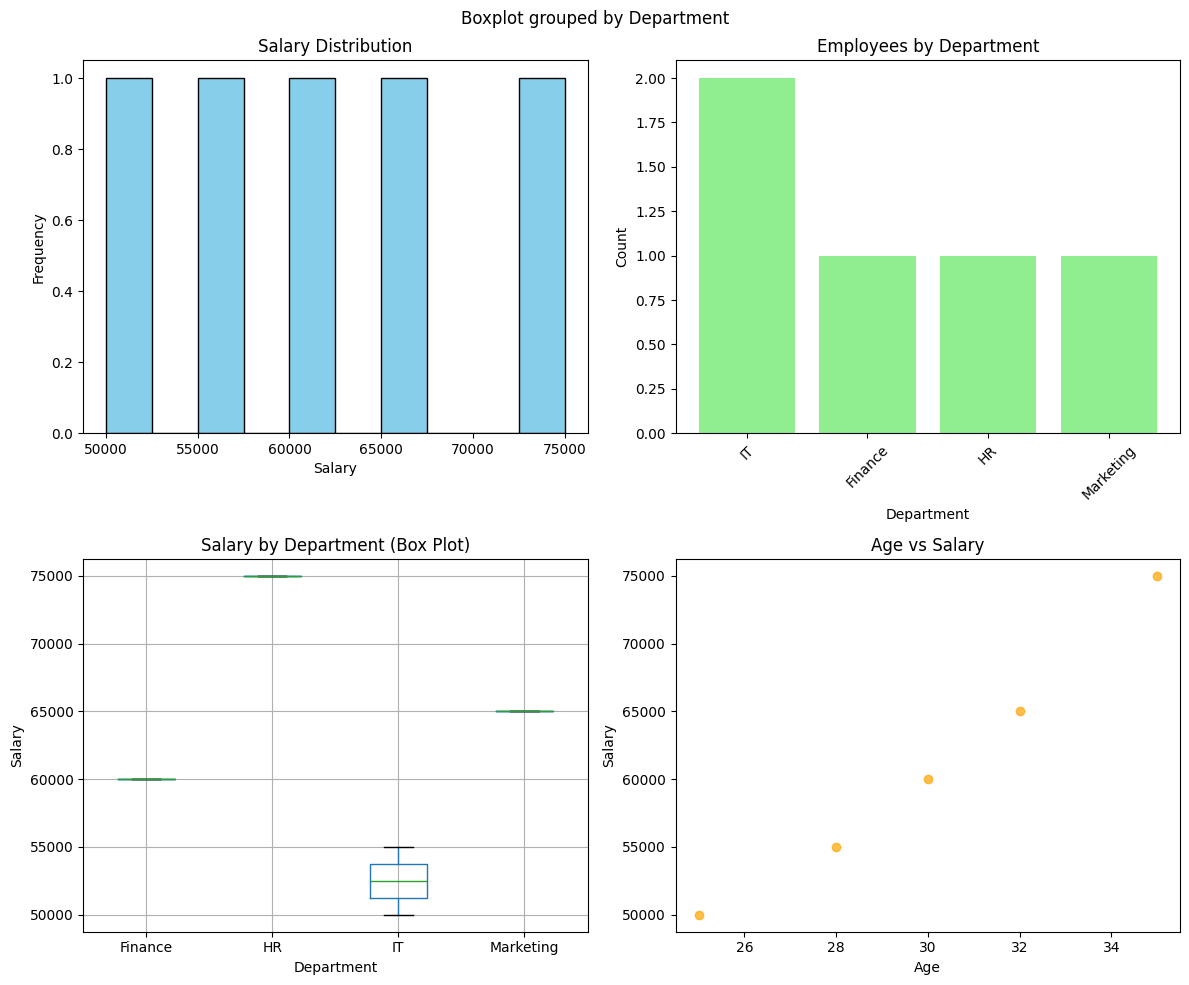

In [10]:
# Data visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Data Analysis Visualizations', fontsize=16)

# Plot 1: Histogram of a numeric column
if 'Salary' in df_clean.columns:
    axes[0, 0].hist(df_clean['Salary'], bins=10, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Salary Distribution')
    axes[0, 0].set_xlabel('Salary')
    axes[0, 0].set_ylabel('Frequency')

# Plot 2: Bar chart of categorical data
if 'Department' in df_clean.columns:
    dept_counts = df_clean['Department'].value_counts()
    axes[0, 1].bar(dept_counts.index, dept_counts.values, color='lightgreen')
    axes[0, 1].set_title('Employees by Department')
    axes[0, 1].set_xlabel('Department')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Box plot
if 'Salary' in df_clean.columns and 'Department' in df_clean.columns:
    df_clean.boxplot(column='Salary', by='Department', ax=axes[1, 0])
    axes[1, 0].set_title('Salary by Department (Box Plot)')
    axes[1, 0].set_xlabel('Department')
    axes[1, 0].set_ylabel('Salary')

# Plot 4: Scatter plot
if 'Age' in df_clean.columns and 'Salary' in df_clean.columns:
    axes[1, 1].scatter(df_clean['Age'], df_clean['Salary'], color='orange', alpha=0.7)
    axes[1, 1].set_title('Age vs Salary')
    axes[1, 1].set_xlabel('Age')
    axes[1, 1].set_ylabel('Salary')

plt.tight_layout()
plt.show()

## 7. Exporting Data <a id="exporting"></a>

After cleaning and analyzing, you might want to export the results:

In [11]:
# Export to Excel
output_file = 'cleaned_data.xlsx'
df_clean.to_excel(output_file, index=False)
print(f"Cleaned data exported to '{output_file}'")

# Export to CSV
csv_file = 'cleaned_data.csv'
df_clean.to_csv(csv_file, index=False)
print(f"Cleaned data exported to '{csv_file}'")

# Export multiple sheets to Excel
if 'all_sheets' in locals():
    with pd.ExcelWriter('multiple_sheets_output.xlsx') as writer:
        for sheet_name, data in all_sheets.items():
            data.to_excel(writer, sheet_name=sheet_name, index=False)
    print("Multiple sheets exported to 'multiple_sheets_output.xlsx'")

Cleaned data exported to 'cleaned_data.xlsx'
Cleaned data exported to 'cleaned_data.csv'
Multiple sheets exported to 'multiple_sheets_output.xlsx'


## 8. Practice Exercise <a id="practice"></a>

Try these exercises with your own Excel file:

1. **Import your Excel file**: Replace the file path with your actual Excel file
2. **Explore the data**: Use the commands above to understand your dataset
3. **Clean the data**: Handle missing values and duplicates
4. **Analyze the data**: Calculate statistics and create visualizations
5. **Export results**: Save your cleaned data to a new Excel file

In [12]:
# Practice space - Add your code here
# 1. Import your Excel file
# your_file = 'path/to/your/file.xlsx'
# your_df = pd.read_excel(your_file)

# 2. Explore the data
# print(your_df.head())
# print(your_df.info())
# print(your_df.describe())

# 3. Clean the data
# your_df_clean = your_df.dropna()  # or other cleaning operations

# 4. Analyze the data
# your_analysis = your_df_clean.groupby('column_name').agg({'another_column': 'mean'})

# 5. Export results
# your_df_clean.to_excel('your_output_file.xlsx', index=False)

print("Add your practice code above!")

Add your practice code above!


## Summary

In this notebook, you learned how to:

- **Import Excel files** using `pd.read_excel()`
- **Work with multiple sheets** in Excel files
- **Explore data** using basic pandas functions
- **Clean data** by handling missing values and duplicates
- **Analyze data** with groupby operations and statistics
- **Visualize data** using matplotlib
- **Export data** to Excel and CSV formats

### Key Functions to Remember:

- `pd.read_excel()` - Import Excel files
- `df.head()` - View first few rows
- `df.info()` - Get dataset information
- `df.describe()` - Statistical summary
- `df.isnull().sum()` - Check missing values
- `df.groupby()` - Group data for analysis
- `df.to_excel()` - Export to Excel

These skills form the foundation for data analysis in Python and are essential for working with business data!